In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

plt.style.use('ggplot')

BASE = Path('.')
OUTPUT = BASE / 'outputs'
OUTPUT.mkdir(exist_ok=True)

In [4]:
fund_master = pd.read_csv('C:\\Users\\rekal\\OneDrive\\Desktop\\MutualFundAnalytics\\data\\processed\\01_fund_master.csv')
nav = pd.read_csv('C:\\Users\\rekal\\OneDrive\\Desktop\\MutualFundAnalytics\\data\\processed\\02_nav_history.csv')
benchmark = pd.read_csv('C:\\Users\\rekal\\OneDrive\\Desktop\\MutualFundAnalytics\\data\\processed\\10_benchmark_indices.csv')

nav.columns = nav.columns.str.strip().str.lower()
fund_master.columns = fund_master.columns.str.strip().str.lower()
benchmark.columns = benchmark.columns.str.strip().str.lower()

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

nav = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print('Funds:', nav['amfi_code'].nunique())
nav.head()

Funds: 40


,amfi_code,date,nav,scheme_name,daily_return
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210


In [5]:
distribution_summary = (
    nav.groupby(['amfi_code', 'scheme_name'])['daily_return']
       .agg(
           mean_daily_return='mean',
           std_daily_return='std',
           min_return='min',
           max_return='max'
       )
       .reset_index()
)

distribution_summary.to_csv(
    OUTPUT / 'distribution_summary.csv',
    index=False
)

distribution_summary.head()

,amfi_code,scheme_name,mean_daily_return,std_daily_return,min_return,max_return
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.000142,0.009164,-0.024744,0.032145
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.000170,0.002460,-0.008188,0.008837
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,-0.044238,0.041954
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,-0.038121,0.033956
4,101207,ABSL Small Cap Fund - Regular - Growth,0.000424,0.016251,-0.051847,0.054851


In [6]:
def calculate_cagr(df, years):
    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df['date'] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp['nav'].iloc[0]
    end_nav = temp['nav'].iloc[-1]

    return (end_nav / start_nav) ** (1/years) - 1


cagr_results = []

for (code, name), df in nav.groupby(['amfi_code', 'scheme_name']):
    cagr_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'CAGR_1Y': calculate_cagr(df, 1),
        'CAGR_3Y': calculate_cagr(df, 3),
        'CAGR_5Y': calculate_cagr(df, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.to_csv(
    OUTPUT / 'cagr_comparison.csv',
    index=False
)

cagr_df.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039127
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533


In [7]:
RF = 0.065
RF_DAILY = RF / 252

sharpe_results = []

for (code, name), df in nav.groupby(['amfi_code', 'scheme_name']):
    r = df['daily_return'].dropna()

    if len(r) < 2 or r.std() == 0:
        sharpe = np.nan
    else:
        sharpe = ((r.mean() - RF_DAILY) / r.std()) * np.sqrt(252)

    sharpe_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'Sharpe': sharpe
    })

sharpe_df = (
    pd.DataFrame(sharpe_results)
      .sort_values('Sharpe', ascending=False)
)

sharpe_df.to_csv(
    OUTPUT / 'sharpe_ratio.csv',
    index=False
)

sharpe_df.head()

,amfi_code,scheme_name,Sharpe
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,120843,Kotak Flexicap Fund - Regular - Growth,1.306744
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101


In [8]:
benchmark.rename(
    columns={
        'close': 'market_nav',
        'close_value': 'market_nav',
        'index value': 'market_nav'
    },
    inplace=True
)

if 'index_name' in benchmark.columns:
    nifty100 = benchmark[
        benchmark['index_name'].str.upper().str.contains('100')
    ].copy()
else:
    nifty100 = benchmark.copy()

nifty100['market_return'] = nifty100['market_nav'].pct_change()

alpha_beta = []

for (code, name), df in nav.groupby(['amfi_code', 'scheme_name']):
    merged = df.merge(
        nifty100[['date', 'market_return']],
        on='date',
        how='inner'
    ).dropna()

    if len(merged) < 2:
        alpha = beta = r2 = np.nan
    else:
        slope, intercept, r, p, se = linregress(
            merged['market_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope
        r2 = r**2

    alpha_beta.append({
        'amfi_code': code,
        'scheme_name': name,
        'Alpha': alpha,
        'Beta': beta,
        'R_squared': r2
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.to_csv(
    OUTPUT / 'alpha_beta.csv',
    index=False
)

alpha_beta_df.head()

,amfi_code,scheme_name,Alpha,Beta,R_squared
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268,0.002665
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158,0.000015
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,0.000012
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,0.000348
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,0.001064


In [9]:
drawdowns = []

for (code, name), df in nav.groupby(['amfi_code', 'scheme_name']):
    running_max = df['nav'].cummax()
    dd = df['nav'] / running_max - 1

    end_idx = dd.idxmin()
    end_date = df.loc[end_idx, 'date']

    peak_idx = df.loc[:end_idx, 'nav'].idxmax()
    start_date = df.loc[peak_idx, 'date']

    drawdowns.append({
        'amfi_code': code,
        'scheme_name': name,
        'Max_Drawdown': dd.min(),
        'Drawdown_Start': start_date,
        'Drawdown_End': end_date
    })

drawdown_df = pd.DataFrame(drawdowns)

drawdown_df.to_csv(
    OUTPUT / 'drawdown.csv',
    index=False
)

drawdown_df.head()

,amfi_code,scheme_name,Max_Drawdown,Drawdown_Start,Drawdown_End
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-03-11,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11


In [10]:
scorecard = (
    cagr_df.merge(
        sharpe_df,
        on=['amfi_code', 'scheme_name']
    ).merge(
        alpha_beta_df,
        on=['amfi_code', 'scheme_name']
    ).merge(
        drawdown_df[['amfi_code', 'scheme_name', 'Max_Drawdown']],
        on=['amfi_code', 'scheme_name']
    )
)

scorecard['CAGR_score'] = scorecard['CAGR_5Y'].rank(pct=True)
scorecard['Sharpe_score'] = scorecard['Sharpe'].rank(pct=True)
scorecard['Alpha_score'] = scorecard['Alpha'].rank(pct=True)
scorecard['Drawdown_score'] = (
    (-scorecard['Max_Drawdown']).rank(pct=True)
)

scorecard['Score'] = (
    0.40 * scorecard['CAGR_score'] +
    0.25 * scorecard['Sharpe_score'] +
    0.20 * scorecard['Alpha_score'] +
    0.15 * scorecard['Drawdown_score']
)

scorecard['Rank'] = (
    scorecard['Score']
      .rank(ascending=False, method='dense')
      .astype(int)
)

scorecard = scorecard.sort_values('Rank')

scorecard.to_csv(
    OUTPUT / 'fund_scorecard.csv',
    index=False
)

scorecard.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,R_squared,Max_Drawdown,CAGR_score,Sharpe_score,Alpha_score,Drawdown_score,Score,Rank
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,1.345534e-07,-0.181885,1.000,0.900,0.950,0.625,0.90875,1
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,1.414258e-04,-0.287060,0.975,0.675,1.000,0.900,0.89375,2
39,149324,DSP Small Cap Fund - Regular - Growth,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,3.532991e-05,-0.311719,0.950,0.700,0.975,0.925,0.88875,3
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,1.748889e-04,-0.163967,0.925,0.950,0.925,0.525,0.87125,4
30,120843,Kotak Flexicap Fund - Regular - Growth,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,3.430543e-04,-0.129740,0.875,0.975,0.900,0.325,0.82250,5
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,4.625437e-04,-0.112657,0.900,1.000,0.850,0.200,0.81000,6
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,1.206652e-05,-0.162172,0.850,0.850,0.875,0.500,0.80250,7
38,149323,DSP Midcap Fund - Regular - Growth,0.214812,0.268700,0.256118,1.132122,0.265986,-0.002523,3.357978e-06,-0.172481,0.825,0.875,0.825,0.550,0.79625,8
16,119094,Axis Midcap Fund - Regular - Growth,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,1.936879e-03,-0.209609,0.800,0.750,0.800,0.700,0.77250,9
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,8.869789e-04,-0.150124,0.775,0.925,0.775,0.425,0.76000,10


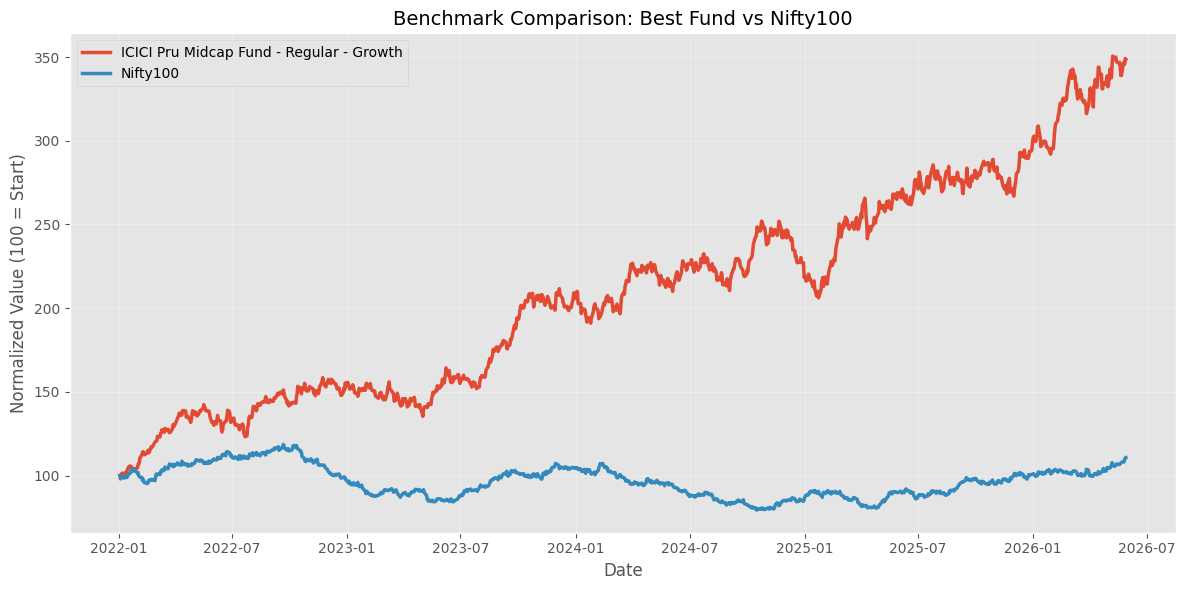

In [11]:
best_code = scorecard.iloc[0]['amfi_code']
best_name = scorecard.iloc[0]['scheme_name']

fund = nav[nav['amfi_code'] == best_code].copy()

merged = fund.merge(
    nifty100[['date', 'market_nav']],
    on='date',
    how='inner'
)

merged['Fund_Index'] = (
    merged['nav'] /
    merged['nav'].iloc[0] * 100
)

merged['Nifty100_Index'] = (
    merged['market_nav'] /
    merged['market_nav'].iloc[0] * 100
)

plt.figure(figsize=(12, 6))

plt.plot(
    merged['date'],
    merged['Fund_Index'],
    label=best_name,
    linewidth=2.5
)

plt.plot(
    merged['date'],
    merged['Nifty100_Index'],
    label='Nifty100',
    linewidth=2.5
)

plt.title(
    'Benchmark Comparison: Best Fund vs Nifty100',
    fontsize=14
)

plt.xlabel('Date')
plt.ylabel('Normalized Value (100 = Start)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT / 'benchmark_comparison.png',
    dpi=300
)

plt.show()

In [12]:
print('Analytics completed successfully')
print()
print('Files generated in outputs/:')
print('- distribution_summary.csv')
print('- cagr_comparison.csv')
print('- sharpe_ratio.csv')
print('- alpha_beta.csv')
print('- drawdown.csv')
print('- fund_scorecard.csv')
print('- benchmark_comparison.png')
print()
print('Top 10 funds:')
scorecard[['Rank', 'scheme_name', 'Score']].head(10)

Analytics completed successfully

Files generated in outputs/:
- distribution_summary.csv
- cagr_comparison.csv
- sharpe_ratio.csv
- alpha_beta.csv
- drawdown.csv
- fund_scorecard.csv
- benchmark_comparison.png

Top 10 funds:


,Rank,scheme_name,Score
25,1,ICICI Pru Midcap Fund - Regular - Growth,0.90875
21,2,SBI Small Cap Fund - Regular Plan - Growth,0.89375
39,3,DSP Small Cap Fund - Regular - Growth,0.88875
36,4,Mirae Asset Tax Saver Fund - Regular - Growth,0.87125
30,5,Kotak Flexicap Fund - Regular - Growth,0.82250
34,6,Mirae Asset Large Cap Fund - Regular - Growth,0.81000
2,7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.80250
38,8,DSP Midcap Fund - Regular - Growth,0.79625
16,9,Axis Midcap Fund - Regular - Growth,0.77250
19,10,SBI Bluechip Fund - Regular Plan - Growth,0.76000
